# CarbonLens
# UIC CS 418, Fall 2025 Final Project
**Authors: Karthik Kesavarapu, Shri Chatrati, Shounak Sawant, Rahee Chauhan**

## Project Introduction:

As there is an increasing concern about the prevalent issues that are starting to arise with global warming, consumers are starting to become more aware of the products that release more carbon emmissions. However, some applications may not include specific carbon data, and if they do consumers are not sure if it is the appropriate and eco-friendly which ultimately leaves buyers unaware of the true environmental cost of their choices. CarbonLens aims to solve this problem by predicting the CO2 emissions of appliances using machine learning, based on publicly available features such as energy usage, materials, and origin. 

The purpose of this application is to hypothesize whether or not a product's CO2 emissions can be accurately estimated with quantitative and qualitative being predicted. In other words, we propose that machine learnning can estimate the carbon footprint of appliances based on standard specification data, which will increase customer awareness of environmental impact. 

## Project Changes Since Proposal:
One of the major changes since the project proposal was the scope of the data. Our plan originally had a CO2 emmissions dataset and a database. We are choosing as a group to get rid of these two datasets as it confuses of what the scope of the project actually is. The very first dataset that we have just talks about the carbon emmissions over time which alraedy has a data visualization in the website. Furthermore, it is common knowledge, we also assume that our audience knows this, that the industrial revolution in 1960 caused a rise of CO2 emmissions. Instead of these two datasets, we are opting to choose a dataset from energystar.gov which is a US private company that keeps track of emmissions of different appliances. This also solidifies the scope of the project as now our project will examine the CO2 Emissions in the United Staes of America. 

## Energy Star Certified Product Data Sets
Within this dataset, there are so many different appliances that are grouped by different categories. We have decided to pick categories that people are expected to use almost daily which includes appliances, heating and cooling, electronics and home office, lighting and fans, and vehicle charging. Althoguh this may seem like a bias for appliances that will emmit a lot more carbon dioxide because it is used more, it falls under the scope of the project because we are trying to find out the patterns of CO2 emmissions from daily used products. From these different appliances, we used a simple random sample (SRS) so that all of the appliances have an equal opportunity of being picked. 

The appliances that we are going to use are:
1. Refrigerators
2. Room Air Conditioners
3. Televisions
4. Ceiling Fans
5. Ovens

This is a good stratification of 5 different types of appliances that will show the overall trends of CO2 usage in daily appliances

## Imports for this project:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, datetime

## Part I: Data Preparation
In this section, we are going to prepare the data from the source.

**Obtaining and Cleaning Refrigerator Data**

In [21]:
dfRefrigerator = pd.read_csv('Residential Refrigerators.csv')
# Display the first few rows of the dataframe
print(dfRefrigerator.head())
print(dfRefrigerator.columns.tolist())

   ENERGY STAR Unique ID Brand Name    Model Number  \
0                4015668        ABL        AREF18**   
1                4015667        ABL         AREF18B   
2                4015665        ABL         AREF18S   
3                4015666        ABL         AREF18W   
4                2403036   Absocold  ARD1033FB21R/L   

  Additional Model Information  UPC         Type  \
0                          NaN  NaN  Top Freezer   
1                          NaN  NaN  Top Freezer   
2                          NaN  NaN  Top Freezer   
3                          NaN  NaN  Top Freezer   
4                          NaN  NaN  Top Freezer   

                                       Product Class Defrost Type Compact  \
0  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
1  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
2  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
3  3 - Refrigerator-freezers - automatic defrost

This is a lot of columns with a lot of data information. Let's try cleaning it up!

In [22]:
# 1. Drop duplicates
df = dfRefrigerator.drop_duplicates()

# 2. Remove completely empty columns
df = df.dropna(axis=1, how='all')

# 3. Remove rows missing key values
df = df.dropna(subset=["Brand Name", "Model Number", "Annual Energy Use (kWh/yr)", "Additional Model Information"])

# 4. Convert numeric columns to proper types
numeric_cols = [
    "Annual Energy Use (kWh/yr)",
    "US Federal Standard (kWh/yr)",
    "Percent Less Energy Use than US Federal Standard",
    "Height (in)",
    "Width (in)",
    "Capacity (Total Volume) (ft3)"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Drop rows with invalid or 0 energy values
df = df[df["Annual Energy Use (kWh/yr)"] > 0]

# 6. Standardize brand names
df["Brand Name"] = df["Brand Name"].str.strip().str.title()

# 7. Convert all Yes/No columns to 1/0
for col in df.columns:
    if df[col].isin(['Yes', 'No']).any():
        df[col] = df[col].replace({'Yes': 1, 'No': 0})


# 8. Reset index
df = df.reset_index(drop=True)

# 9. Convert date columns to proper datetime objects
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

# 10. Preview cleaned data
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   ENERGY STAR Unique ID                                   604 non-null    int64         
 1   Brand Name                                              604 non-null    object        
 2   Model Number                                            604 non-null    object        
 3   Additional Model Information                            604 non-null    object        
 4   UPC                                                     375 non-null    object        
 5   Type                                                    602 non-null    object        
 6   Product Class                                           604 non-null    object        
 7   Defrost Type                                            593 no

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/762155161.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


**Obtaining and Cleaning the Air Conditioner Data**

In [23]:
dfAirConditioner = pd.read_csv('Room Air Conditioners.csv')
# Display the first few rows of the dataframe
print(dfAirConditioner.head())
print(dfAirConditioner.columns.tolist())

   ENERGY STAR Unique ID    Brand Name Model Number  \
0                3387785  BLACK+DECKER     BD08NWES   
1                3387786  BLACK+DECKER     BD10NWES   
2                3387787  BLACK+DECKER     BD12NWES   
3                3629713       Century    RXTS-101A   
4                3629714       Century    RXTS-121A   

  Additional Model Information           UPC  Height (inches)  Width (inches)  \
0                          NaN  810064695360             13.5            18.6   
1                          NaN  810064695377             13.5            18.6   
2                          NaN  810064695384             14.6            19.1   
3                          NaN           NaN             13.5            19.2   
4                          NaN           NaN             13.5            19.2   

   Depth (inches)  Weight (lbs) Cooling Capacity (Btu/hr)  ...  \
0            19.6          44.1                     8,000  ...   
1            19.6          46.1                   

In [24]:
# 1. Drop duplicates
df = dfAirConditioner.drop_duplicates()

# 2. Remove completely empty columns
df = df.dropna(axis=1, how='all')

# 3. Remove rows missing key values
df = df.dropna(subset=["Brand Name", "Model Number", "Annual Energy Use (kWh/yr)", "Additional Model Information"])

# 4. Convert numeric columns
numeric_cols = [
    "Annual Energy Use (kWh/yr)",
    "Cooling Capacity (Btu/hr)",
    "Voltage (volts)",
    "Percent Less Energy Use than US Federal Standard",
    "Combined Energy Efficiency Ratio (CEER)"
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Drop invalid or zero energy values
df = df[df["Annual Energy Use (kWh/yr)"] > 0]

# 6. Standardize brand names
df["Brand Name"] = df["Brand Name"].str.strip().str.title()

# 7. Convert Yes/No to 1/0
for col in df.columns:
    if df[col].isin(['Yes', 'No']).any():
        df[col] = df[col].replace({'Yes': 1, 'No': 0})

# 8. Reset index
df = df.reset_index(drop=True)

# 9. Convert date columns to proper datetime objects
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

# 10. Preview
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 28 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   ENERGY STAR Unique ID                             14 non-null     int64         
 1   Brand Name                                        14 non-null     object        
 2   Model Number                                      14 non-null     object        
 3   Additional Model Information                      14 non-null     object        
 4   UPC                                               12 non-null     object        
 5   Height (inches)                                   14 non-null     float64       
 6   Width (inches)                                    14 non-null     float64       
 7   Depth (inches)                                    14 non-null     float64       
 8   Weight (lbs)                    

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/156744858.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


**Obtaining and Cleaning the Television Data**

In [25]:
dfTelevisionData = pd.read_csv('Televisions.csv')
# Display the first few rows of the dataframe
print(dfTelevisionData.head())
print(dfTelevisionData.columns.tolist())

   ENERGY STAR Unique ID                                ENERGY STAR Partner  \
0                2402123                          Curtis International Ltd.   
1                2403227  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
2                3554271  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
3                2399940  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
4                3554326  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   

  Brand Name Model Name Model Number  \
0        RCA       65D1         65D1   
1     Sansui    LE-24T1      LE-24T1   
2     Sansui   LE-24TA1     LE-24TA1   
3     Sansui    LE-32T1      LE-32T1   
4     Sansui    LE-32V1      LE-32V1   

                        Additional Model Information  UPC     Product Type  \
0  ,65N1,; ,RTAU6504,; ,RTAU6540.,; ,RTRU6527,; ,...  NaN  Television (TV)   
1  ,EC24T1H,; ,EC24T1HA,; ,EC24T1HN,; ,EC24T2H,; ...  NaN  Television (TV)   
2  ,****24****.,; ,C24V1HW,; ,C24VAHW,; ,LE-24T1,.

In [26]:
# 1. Drop duplicates
df = dfTelevisionData.drop_duplicates()

# 2. Drop fully empty columns
df = df.dropna(axis=1, how='all')

# 3. Drop rows missing essential identifiers
df = df.dropna(subset=["Brand Name", "Model Number", "Reported Annual Energy Consumption (kWh)"])

# 4. Clean numeric columns
numeric_cols = [
    "Reported Annual Energy Consumption (kWh)",
    "Average On Mode Power Consumption for Certification (watts)",
    "Maximum Average On Mode Power for Certification (watts)",
    "Reported On Mode Power (per the Federal Test Procedure) (watts)",
    "Measured Standby Mode Power (Watts)",
    "Power Consumption in Standby Mode when Not Connected to a Network (watts)",
    "Power Consumption in Standby Mode when Connected to a Network (watts)",
    "Reported Standby-Active, Low Mode Power (watts)",
    "Diagonal Viewable Screen Size (in.)",
    "Screen Area (sq. in.)",
    "Native Horizontal Resolution (pixels)",
    "Native Vertical Resolution (pixels)"
]

for col in numeric_cols:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.replace(',', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 5. Remove rows with invalid or zero energy consumption
df = df[df["Reported Annual Energy Consumption (kWh)"] > 0]

# 6. Normalize brand names
df["Brand Name"] = df["Brand Name"].str.strip().str.title()

# 7. Convert Yes/No to 1/0
for col in df.columns:
    if df[col].isin(['Yes', 'No']).any():
        df[col] = df[col].replace({'Yes': 1, 'No': 0})

# 8. Convert date columns to datetime
from datetime import datetime
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%m/%d/%Y", errors="coerce")

# 9. Reset index
df = df.reset_index(drop=True)

# 10. Preview cleaned data
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 35 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype         
---  ------                                                                                                                    --------------  -----         
 0   ENERGY STAR Unique ID                                                                                                     146 non-null    int64         
 1   ENERGY STAR Partner                                                                                                       146 non-null    object        
 2   Brand Name                                                                                                                146 non-null    object        
 3   Model Name                                                                                          

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/2699546209.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


**Obtaining and Cleaning Data the Ceiling Fans Data**

In [27]:
dfCeilingFans = pd.read_csv('Ceiling Fans.csv')
# Display the first few rows of the dataframe
print(dfCeilingFans.head())
print(dfCeilingFans.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner Brand Name   Model Name  \
0                2386171    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
1                2385543    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
2                2386170    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
3                2385542    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
4                2386169    Aeratron Pty Ltd   AERATRON  Ceiling Fan   

   Model Number              Additional Model Information  \
0   AE+2WI43***  ,,Each * to represent a letter or blank.   
1  AE+2WI43L***  ,,Each * to represent a letter or blank.   
2   AE+2WI50***  ,,Each * to represent a letter or blank.   
3  AE+2WI50L***  ,,Each * to represent a letter or blank.   
4   AE+2WI60***  ,,Each * to represent a letter or blank.   

                                                 UPC      Indoor/Outdoor  \
0  850021862015;850021862022;850021862039;8500218...  Indoor Ceiling Fan   
1  850021862015;850021862022;850021862039;850021

In [28]:
# 1. Clean column names (remove hidden spaces)
dfCeilingFans.columns = dfCeilingFans.columns.str.strip()

# 2. Drop duplicates
dfCeilingFans = dfCeilingFans.drop_duplicates()

# 3. Drop fully empty columns
dfCeilingFans = dfCeilingFans.dropna(axis=1, how='all')

# 4. Remove rows missing key info
dfCeilingFans = dfCeilingFans.dropna(subset=["Brand Name", "Model Number", "Ceiling Fan Efficiency (CFM/W)"])

# 5. Convert numeric columns
numeric_cols = [
    "Blade Span (Diameter) (in.)",
    "Ceiling Fan Efficiency (CFM/W)",
    "Fan Power Consumption-Low Speed (W)",
    "Fan Power Consumption-High Speed (W)",
    "Fan Power Consumption-Standby (W)",
    "Ceiling Fan Components Warranty (Years)",
    "Total Light Output (lumens)",
    "Total Lighting Input Power (Watts)",
    "Lighting Efficiency – Measured outside the Fixture (lm/W)",
    "Lighting Efficiency – Measured at the Source (lm/W)",
    "Power Factor of Light Kit",
    "Light Color Appearance (CCT)",
    "Light Color Quality (CRI)",
    "Light Source Rated Life (Hours)",
    "Light Sources Per Light Kit",
    "Ceiling Fan Light Kit Warranty (yrs)"
]

for col in numeric_cols:
    if col in dfCeilingFans.columns:
        if dfCeilingFans[col].dtype == object:
            dfCeilingFans[col] = dfCeilingFans[col].str.replace(',', '', regex=True)
        dfCeilingFans[col] = pd.to_numeric(dfCeilingFans[col], errors="coerce")

# 6. Drop rows with invalid or zero efficiency
dfCeilingFans = dfCeilingFans[dfCeilingFans["Ceiling Fan Efficiency (CFM/W)"] > 0]

# 7. Normalize brand names
dfCeilingFans["Brand Name"] = dfCeilingFans["Brand Name"].str.strip().str.title()

# 8. Convert Yes/No columns to 1/0
for col in dfCeilingFans.columns:
    if dfCeilingFans[col].isin(['Yes', 'No']).any():
        dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})

# 9. Convert dates to datetime
from datetime import datetime
date_cols = ["Date Available on Market", "Date Certified"]
for col in date_cols:
    if col in dfCeilingFans.columns:
        dfCeilingFans[col] = pd.to_datetime(dfCeilingFans[col], format="%m/%d/%Y", errors="coerce")

# 10. Reset index
dfCeilingFans = dfCeilingFans.reset_index(drop=True)

# 11. Preview cleaned data
print(dfCeilingFans.info())
print(dfCeilingFans.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 32 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   ENERGY STAR Unique ID                           1144 non-null   int64         
 1   ENERGY STAR Partner                             1144 non-null   object        
 2   Brand Name                                      1144 non-null   object        
 3   Model Name                                      1144 non-null   object        
 4   Model Number                                    1144 non-null   object        
 5   Additional Model Information                    542 non-null    object        
 6   UPC                                             642 non-null    object        
 7   Indoor/Outdoor                                  1144 non-null   object        
 8   Product Type                                    

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/876389756.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})


**Obtaining and Cleaning Data the Ovens Data**

In [62]:
dfOvens = pd.read_csv('Ovens.csv')
# Display the first few rows of the dataframe
print(dfOvens.head())
print(dfOvens.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner                    Brand Name  \
0                3942789    Alto-Shaam, Inc.                    Alto-Shaam   
1                3722150    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
2                3722082    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
3                2407803    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
4                2407802    Alto-Shaam, Inc.      Alto-Shaam - Prodigi Pro   

  Model Name Model Number Additional Model Information  UPC Product Type  \
0  CTP10-20G    CTP10-20G                          NaN  NaN  Combination   
1  CTC20-10G    CTC20-10G                          NaN  NaN  Combination   
2  CTC20-20E    CTC20-20E                          NaN  NaN  Combination   
3  CTP20-20G    CTP20-20G                          NaN  NaN  Combination   
4  CTC20-20G    CTC20-20G                          NaN  NaN  Combination   

                                 Oven Classification       Size  ...  \
0 

In [63]:
# 1) Drop dups / empty cols
dfOvens = dfOvens.drop_duplicates()
dfOvens = dfOvens.dropna(axis=1, how='all')

# 2) Drop rows missing core identifiers
core_cols = ["Brand Name", "Model Number", "Product Type"]
present_core = [c for c in core_cols if c in dfOvens.columns]
if present_core:
    dfOvens = dfOvens.dropna(subset=present_core)

# 3) Numeric conversions (only if column exists)
numeric_cols = [
    "Input Rate (kW)",
    "Input Rate (Btu/hr)",
    "Gas Oven Convection Mode Pre-Heat Energy (Btu)",
    "Electric Oven Convection Mode Pre-Heat Energy (kWh)",
    "Convection Mode Pre-Heat Time (min)",
    "Gas Oven Steam Mode Pre-Heat Energy (Btu)",
    "Electric Oven Steam Mode Pre-Heat Energy (kWh)",
    "Steam Mode Pre-Heat Time (min)",
    "Electric Oven Convection Mode Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Convection Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Total Idle Energy Rate (Btu/hr)",
    "Half-Size and Full-Size Steam Pan Capacity",
    "Two-Thirds-Size Steam Pan Capacity",
    "Half-Size Sheet Pan Capacity",
    "Full-Size Sheet Pan Capacity",
    "Electric Oven Steam Mode Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Steam Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Total Idle Energy Rate (Btu/hr)",
    "Convection Mode Cooking Energy Efficiency (%)",
    "Steam Mode Cooking Energy Efficiency (%)",
    "Convection Mode Production Capacity (lbs/hr)",
    "Steam Mode Production Capacity (lbs/hr)",
    "Convection Mode Cooking Period Water Consumption (gal/pan)",
    "Convection Mode Idle Period Water Consumption (gal/hr/pan)",
    "Steam Mode Cooking Period Water Consumption (gal/pan)",
    "Steam Mode Idle Period Water Consumption (gal/hr/pan)",
    "Rack Oven Baking-Energy Efficiency (%)",
    "Baking Production Capacity (lbs/hr)",
    "Steam Injection Period Water Consumption (gal/min)"
]

for col in numeric_cols:
    if col in dfOvens.columns:
        # strip and remove commas
        dfOvens[col] = (
            dfOvens[col]
            .astype(str)
            .str.strip()
            .str.replace(",", "", regex=True)
            .replace({"": None})
        )
        dfOvens[col] = pd.to_numeric(dfOvens[col], errors="coerce")

# 4) Normalize brand names
if "Brand Name" in dfOvens.columns:
    dfOvens["Brand Name"] = dfOvens["Brand Name"].astype(str).str.strip().str.title()

# 5) Yes/No -> 1/0
for col in dfOvens.columns:
    if dfOvens[col].isin(["Yes", "No"]).any():
        dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})

# 6) Date parsing
for dcol in ["Date Available on Market", "Date Certified"]:
    if dcol in dfOvens.columns:
        dfOvens[dcol] = pd.to_datetime(dfOvens[dcol], format="%m/%d/%Y", errors="coerce")

# 7) Sanity bounds (efficiency % between 0 and 100)
for ecol in ["Convection Mode Cooking Energy Efficiency (%)",
             "Steam Mode Cooking Energy Efficiency (%)",
             "Rack Oven Baking-Energy Efficiency (%)"]:
    if ecol in dfOvens.columns:
        dfOvens.loc[(dfOvens[ecol] < 0) | (dfOvens[ecol] > 100), ecol] = pd.NA

# 8) Reset index and preview
dfOvens = dfOvens.reset_index(drop=True)
print(dfOvens.info())
print(dfOvens.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 48 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   ENERGY STAR Unique ID                                       331 non-null    int64         
 1   ENERGY STAR Partner                                         331 non-null    object        
 2   Brand Name                                                  331 non-null    object        
 3   Model Name                                                  331 non-null    object        
 4   Model Number                                                331 non-null    object        
 5   Additional Model Information                                104 non-null    object        
 6   UPC                                                         11 non-null     object        
 7   Product Type              

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/2950846367.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})


## How did we prepare the data?

There were 5 csv files that we decided to use using the SRS methods from the different stratified categories. For each of these 5 csv files, we dropped duplicate values, got rid of empty columsn, dropped rows missing essential identifiers, cleaned up numeric columns, gave certain attention to percentages and float values, converted Yes/No to 1/0, and finally converted date columns to datetime objects. These are all essential clean up and preparation for the data so that when we analyze it we do not get some weird distribution or our data will not be influenced by any abhorrent outliers. Its also much easier to do for EDA. 

## Part II: Exploratory Data Analysis

In this section, we are going to examine how the datasets look like from a broader perspective and see interesting trends that we can analyze at a much more detailed level. 

### Let's begin by exploring the Refrigerators Data

       ENERGY STAR Unique ID  Height (in)   Width (in)  \
count           4.397000e+03  4397.000000  4397.000000   
mean            2.933870e+06    55.223175    26.699477   
std             7.694902e+05    19.906365     7.365160   
min             2.203489e+06    14.000000    14.200000   
25%             2.365247e+06    33.900000    19.500000   
50%             2.404575e+06    66.400000    25.000000   
75%             3.557110e+06    70.000000    32.800000   
max             4.512365e+06    85.000000    73.200000   

       Capacity (Total Volume) (ft3)  Adjusted Volume (ft3)  \
count                    4397.000000            4397.000000   
mean                       12.829725              15.267592   
std                         8.578882              10.825332   
min                         1.000000               1.000000   
25%                         4.400000               4.400000   
50%                        12.900000              14.400000   
75%                        19.600000

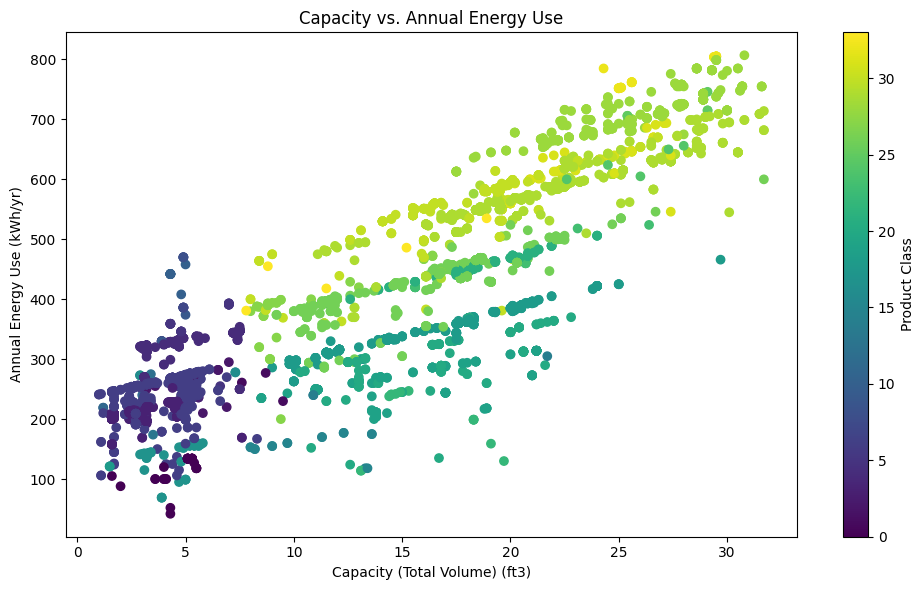

In [74]:
# Load the cleaned Residential Refrigerators dataset
df_refrigerators = pd.read_csv('Residential Refrigerators.csv')


# Display basic statistics
print(df_refrigerators.describe())


# Confirming missing values = 0
missing_values = df_refrigerators.isnull().sum()
print("Missing values per column:\n", missing_values)


# Visualization: Scatter plot of Capacity vs. Annual Energy Use
plt.figure(figsize=(10, 6))
plt.scatter(df_refrigerators["Capacity (Total Volume) (ft3)"], df_refrigerators["Annual Energy Use (kWh/yr)"], c=df_refrigerators["Product Class"].astype('category').cat.codes, cmap="viridis")
plt.title("Capacity vs. Annual Energy Use")
plt.xlabel("Capacity (Total Volume) (ft3)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(label="Product Class")
plt.tight_layout()
plt.show()


## Observations from the Refrigerator Data

- **Positive Trend:** Larger refrigerators use more energy, which makes sense since they have more space to cool.  

- **Clusters:** Product classes form clear groups, showing differences in efficiency and design. 
 
- **Outliers:** Some smaller fridges use more power than expected, while a few big ones are surprisingly efficient.


### Exploring the Room Air Conditioners Data

Summary Stats:
        ENERGY STAR Unique ID  Height (inches)  Width (inches)  Depth (inches)  \
count           2.820000e+02       282.000000      282.000000      282.000000   
mean            3.513323e+06        14.841844       21.356738       22.979787   
std             6.015590e+05         2.059563        3.159109        4.431790   
min             2.453038e+06        11.800000       10.600000       13.800000   
25%             2.838993e+06        13.500000       19.200000       19.675000   
50%             3.557078e+06        13.900000       20.300000       22.000000   
75%             3.892182e+06        15.300000       23.600000       25.400000   
max             4.511256e+06        24.000000       30.000000       41.200000   

       Weight (lbs)  Voltage (volts)  Casement Window  \
count    282.000000       282.000000              0.0   
mean      70.237943       135.336879              NaN   
std       26.583388        43.840093              NaN   
min       35.300000       

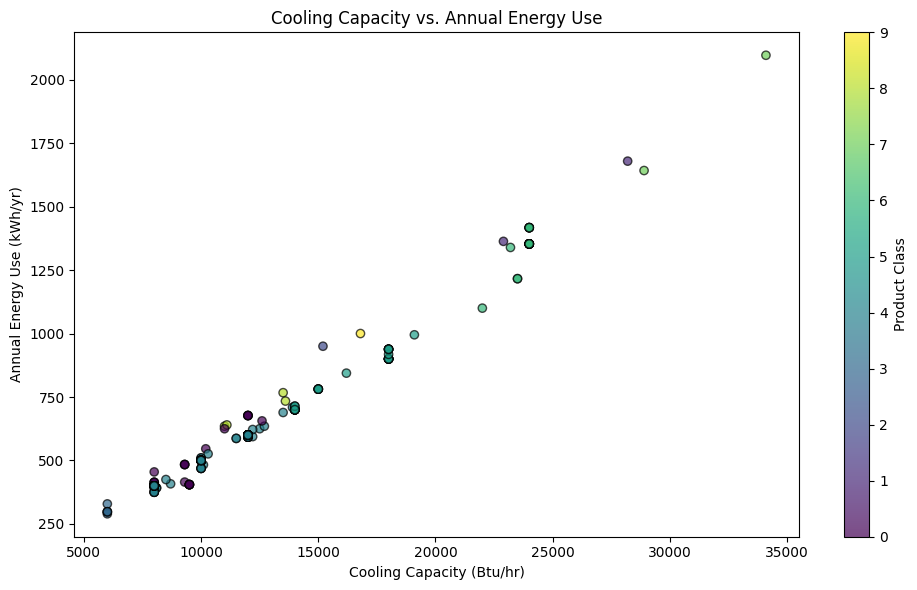

In [73]:
# Load dataset
df_ac = pd.read_csv('Room Air Conditioners.csv')

# Basic info
print("Summary Stats:\n", df_ac.describe())
print("\nMissing Values:\n", df_ac.isnull().sum())

# Keep only rows with valid Cooling Capacity and Energy Use
cols = ["Cooling Capacity (Btu/hr)", "Annual Energy Use (kWh/yr)"]
df_plot = df_ac.dropna(subset=cols)

# Convert to numeric (remove commas, handle blanks)
for col in cols:
    df_plot[col] = (
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA)
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Drop any rows that failed conversion
df_plot = df_plot.dropna(subset=cols)

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[0]],
    df_plot[cols[1]],
    c=df_plot["Product Class"].astype('category').cat.codes,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Cooling Capacity vs. Annual Energy Use")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


## Observations from the Room Air Conditioners Data

- **Positive Trend:** Units with higher cooling capacity use more energy, which makes sense since bigger systems draw more power.  

- **Clusters:** Product classes form clear groups, showing differences in energy use and design.  

- **Outliers:** A few units use more energy than expected for their size, likely due to older or less efficient models.


### Exploring the Television Data

Summary Stats:
        ENERGY STAR Unique ID  Diagonal Viewable Screen Size (in.)  \
count           1.460000e+02                           146.000000   
mean            3.373871e+06                            58.658767   
std             5.683467e+05                            18.519308   
min             2.399940e+06                            13.230000   
25%             2.837273e+06                            49.357500   
50%             3.477606e+06                            54.670000   
75%             3.814830e+06                            74.500000   
max             4.481070e+06                           114.400000   

       Native Horizontal Resolution (pixels)  \
count                             146.000000   
mean                             3398.397260   
std                               944.909311   
min                               768.000000   
25%                              3840.000000   
50%                              3840.000000   
75%                       

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/2436932697.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


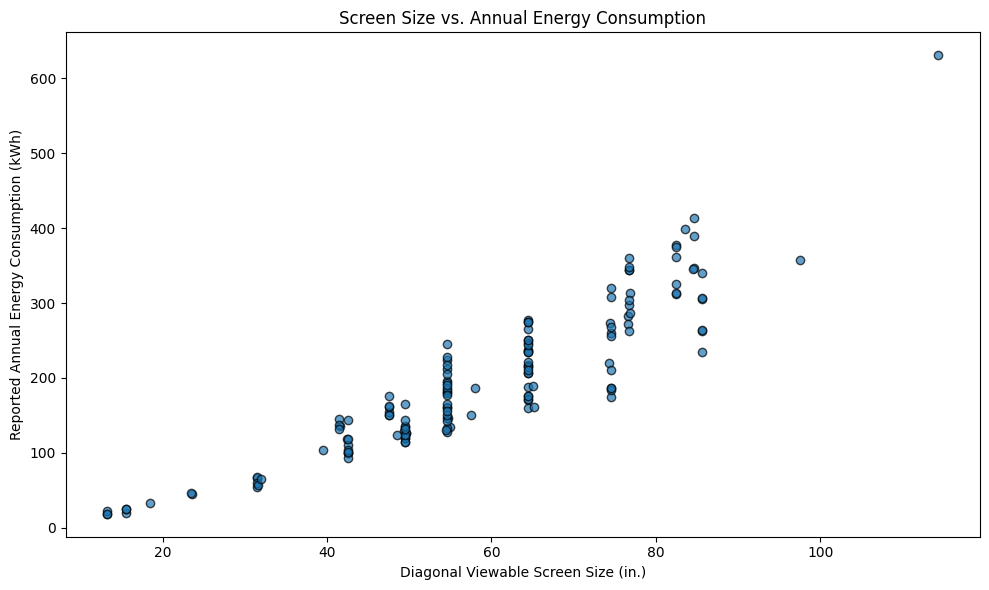

In [70]:
# Load dataset
df_tv = pd.read_csv('Televisions.csv')
print("Summary Stats:\n", df_tv.describe())

# Keep rows with valid screen size and energy data
cols = ["Reported Annual Energy Consumption (kWh)", "Diagonal Viewable Screen Size (in.)"]
df_plot = df_tv.dropna(subset=cols)

# Convert numeric columns (remove commas and blanks)
for col in cols:
    df_plot[col] = pd.to_numeric(
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA),
        errors='coerce'
    )

# Drop invalid rows after conversion
df_plot = df_plot.dropna(subset=cols)

# Plot: Screen Size vs. Annual Energy Consumption
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[1]], df_plot[cols[0]],
    c=df_plot["Product Class"].astype('category').cat.codes if "Product Class" in df_plot.columns else None,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Screen Size vs. Annual Energy Consumption")
plt.xlabel("Diagonal Viewable Screen Size (in.)")
plt.ylabel("Reported Annual Energy Consumption (kWh)")
if "Product Class" in df_plot.columns:
    plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


## Observations from the Television Data

- **Positive Trend:** Larger TVs clearly use more energy, which makes sense since bigger screens need more power. 

- **Size Groups:** TVs cluster around common screen sizes like 40", 55", and 65", showing standard product categories.  

- **Outliers:** A few large TVs use extra energy, likely due to older tech or higher brightness settings.


### Exploring the Ceiling Fans Data

Summary Stats:
        ENERGY STAR Unique ID  Blade Span (Diameter) (in.)  \
count           1.144000e+03                  1144.000000   
mean            3.170131e+06                    55.700175   
std             7.677942e+05                     9.041082   
min             2.313943e+06                    19.000000   
25%             2.389850e+06                    52.000000   
50%             2.856306e+06                    52.000000   
75%             3.943170e+06                    60.000000   
max             4.511663e+06                    84.000000   

       Ceiling Fan Efficiency (CFM/W)  Fan Power Consumption-Low Speed (W)  \
count                     1144.000000                          1082.000000   
mean                       209.056731                             4.651017   
std                         71.468044                             3.241647   
min                         47.400000                             1.000000   
25%                        157.500000       

/var/folders/zn/xbhnvscx74jdrxhs5f16b_w40000gn/T/ipykernel_52725/3310016280.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


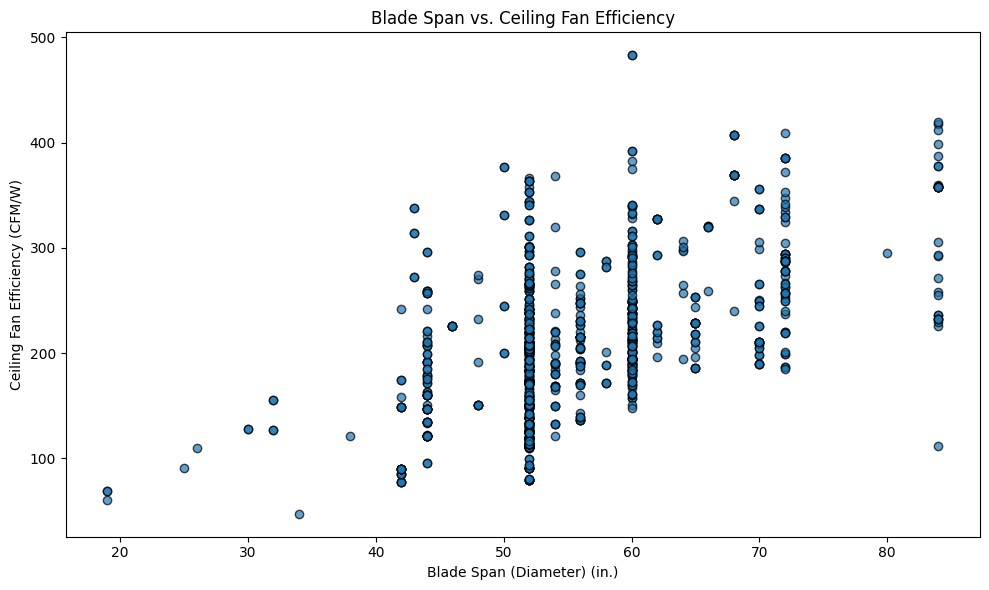

In [72]:
# Load dataset
df_fans = pd.read_csv('Ceiling Fans.csv')
print("Summary Stats:\n", df_fans.describe())

# Keep rows with valid efficiency and blade span values
cols = ["Ceiling Fan Efficiency (CFM/W)", "Blade Span (Diameter) (in.)"]
df_plot = df_fans.dropna(subset=cols)

# Convert numeric columns (remove commas and blanks)
for col in cols:
    df_plot[col] = pd.to_numeric(
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA),
        errors='coerce'
    )

# Drop invalid rows after conversion
df_plot = df_plot.dropna(subset=cols)

# Plot: Blade Span vs. Ceiling Fan Efficiency
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[1]], df_plot[cols[0]],
    c=df_plot["Product Class"].astype('category').cat.codes if "Product Class" in df_plot.columns else None,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Blade Span vs. Ceiling Fan Efficiency")
plt.xlabel("Blade Span (Diameter) (in.)")
plt.ylabel("Ceiling Fan Efficiency (CFM/W)")
if "Product Class" in df_plot.columns:
    plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


### Observations from the Ceiling Fans Data

- **Positive Correlation**: Larger blade spans tend to have higher efficiency, as expected, but the relationship isn't strong as there seems to be alot of variation in the middle range.

- **Distinct Clusters**: Product classes form clear groupings, indicating differences in design and efficiency.

- **Outliers:** A few small fans are surprisingly efficient, while some large fans underperform. This might be due to design differences or newer energy-saving models.

### Exploring the Ovens Data

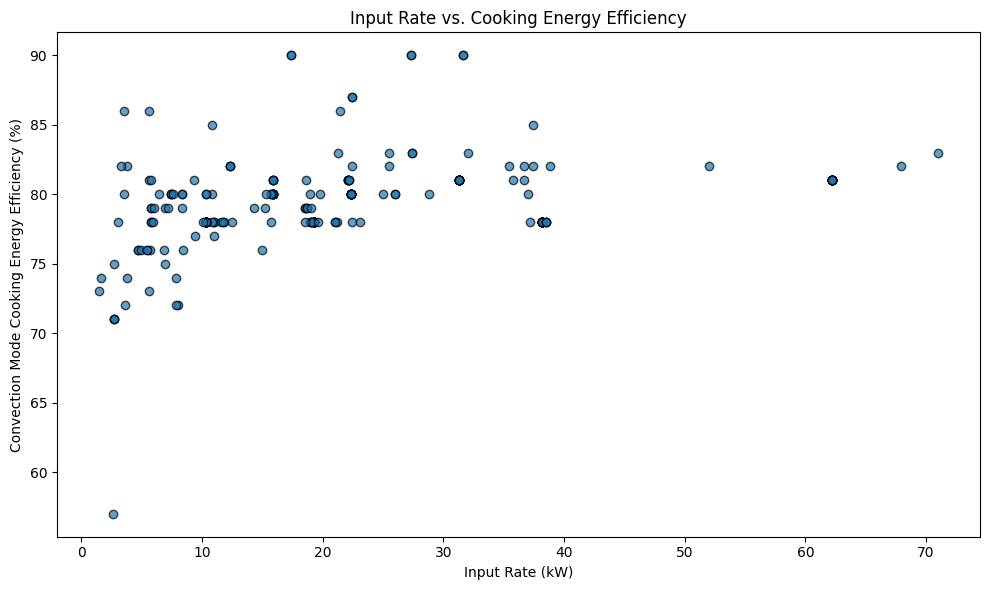

In [66]:
# Load dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Ovens.csv')

# Clean data
df = df.dropna(subset=["Convection Mode Cooking Energy Efficiency (%)", "Input Rate (kW)"])
df["Convection Mode Cooking Energy Efficiency (%)"] = (
    df["Convection Mode Cooking Energy Efficiency (%)"].astype(str).str.replace(',', '').astype(float)
)
df["Input Rate (kW)"] = (
    df["Input Rate (kW)"].astype(str).str.replace(',', '').astype(float)
)

# Fix possible BTU/hr entries
df.loc[df["Input Rate (kW)"] > 1000, "Input Rate (kW)"] /= 3412

# Remove extreme outliers
df = df[df["Input Rate (kW)"] < 500]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Input Rate (kW)"],
    df["Convection Mode Cooking Energy Efficiency (%)"],
    alpha=0.7, edgecolor='k'
)
plt.title("Input Rate vs. Cooking Energy Efficiency")
plt.xlabel("Input Rate (kW)")
plt.ylabel("Convection Mode Cooking Energy Efficiency (%)")
plt.tight_layout()
plt.show()


## Observations from the Ovens Data

- **Weak Correlation:** Efficiency doesn’t change much with input rate. Bigger or more powerful ovens don’t always perform more efficiently — most seem to have similar efficiency levels overall.  

- **Efficiency Range:** Most ovens fall between **70–90% efficiency**, showing that they work pretty consistently overall.

- **Outliers:** A few ovens have **lower efficiency** than expected for their input rate, which could be due to older designs. Some smaller ovens actually perform really well, showing how newer designs are getting better.

- **Pattern:** Most ovens sit around **80% efficiency**, which seems to be the common performance level for most models.
